# MGMT 687: AI-Driven Product Selection — Final Consolidated Notebook

### Pipeline Overview
```
dataset_history.csv
       │
       ├── B1. Title Feature Extraction  (MGMT_687_Title_Extraction)
       ├── B2. Image Feature Extraction  (image_extraction / all_image_features.csv)
       ├── B3. Merge → merged_data.csv   (Finalized_Dataset)
       │
       └── 80/20 Split (stratified, seed=42)
              │
              ├── C. Machine Learning Models
              │     ├── XGBoost v1   (base, no feature engineering)  [xgboost.ipynb]
              │     ├── XGBoost v2   (with feature engineering)      [xgboost_1.ipynb]
              │     └── Random Forest (uses merged features) ← SWAP-READY BLOCK
              │
              └── D. LLM Strategies
                    ├── Strategy 1: Summary context
                    ├── Strategy 2: Raw data (no preprocessing)
                    └── Strategy 3: Full engineered features context
                           │
                           └── E. Compare all models → validation_results_full.csv
```

### ✅ Files Required
| File | Source |
|---|---|
| `dataset_history.csv` | Original data |
| `dataset_new.csv` | 5 new products to select from |
| `all_image_features.csv` | Output of image_extraction notebook (run once separately) |

---

## 0. Setup & Imports

In [19]:
pip install anthropic pandas numpy scikit-learn xgboost matplotlib seaborn requests Pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# !pip install anthropic pandas numpy scikit-learn xgboost matplotlib seaborn requests Pillow scipy shap

import os, re, json, base64, time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy.stats import spearmanr
from anthropic import Anthropic

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix, classification_report
)
from xgboost import XGBClassifier

# ─── API KEY ──────────────────────────────────────────────────────────────────
ANTHROPIC_API_KEY = "API_KEY" # ← paste your key here
client = Anthropic(api_key=ANTHROPIC_API_KEY)

RANDOM_SEED = 42

# ─── LOAD RAW DATA ────────────────────────────────────────────────────────────
df_history = pd.read_csv("dataset_history.csv")
df_new     = pd.read_csv("dataset_new.csv")

print(f"History: {df_history.shape} | New: {df_new.shape}")
print(f"Class balance:\n{df_history['ordered'].value_counts(normalize=True).round(3)}")

History: (331, 5) | New: (5, 4)
Class balance:
ordered
0    0.683
1    0.317
Name: proportion, dtype: float64


---
## A. Business Problem Definition

**Write your narrative here.**
- Decision: Which products to advertise under a fixed budget?
- Success: Higher purchase rate among selected products
- Cost of errors: False Positive = wasted budget; False Negative = lost sale

---
## B. Feature Engineering — Three Sources Combined

### B1. Title-Based Feature Extraction
*(From MGMT_687_Title_Extraction.ipynb — regex-based structured parsing)*

In [21]:
def extract_title_features(row):
    """
    Extracts structured product features from title + price using rule-based parsing.
    Source: MGMT_687_Title_Extraction.ipynb
    """
    title = row['title']
    price = row['price']

    # Gender
    gender = "unknown"
    if re.search(r"\bMen's\b|\bMen\b", title, re.I):   gender = "Men"
    elif re.search(r"\bWomen's\b|\bWomen\b", title, re.I): gender = "Women"

    # Material
    materials = ["Cotton", "Linen", "Silk", "Flannel", "Corduroy"]
    material = "unknown"
    for m in materials:
        if re.search(r"\b" + m + r"\b", title, re.I):
            material = m
            break

    # Product Type
    product_type = "unknown"
    if re.search(r"T-Shirt|T Shirt|Tshirt", title, re.I):  product_type = "T-Shirt"
    elif re.search(r"Polo", title, re.I):                   product_type = "Polo"
    elif re.search(r"Set", title, re.I):                    product_type = "Set"
    elif re.search(r"Shirt", title, re.I):                  product_type = "Shirt"

    # Sleeve / Neck
    sleeve_or_neck = "unknown"
    for sn in ["Long Sleeve", "Short Sleeve", "V-Neck"]:
        if re.search(sn, title, re.I):
            sleeve_or_neck = sn
            break

    # Color & Size (from "/" delimiter)
    color = "unknown"
    size  = "unknown"
    if "/" in title:
        parts = title.split('/')
        size  = parts[-1].strip()
        color_chunk = parts[0].strip()
        to_remove = [gender, material, product_type, sleeve_or_neck,
                     "Men's", "Women's", "Casual", "Checked"]
        clean_color = color_chunk
        for term in to_remove:
            if term != "unknown":
                clean_color = re.sub(re.escape(term), "", clean_color, flags=re.I)
        color = re.sub(r'\s+', ' ', clean_color).strip() or "unknown"

    # Style Category
    style_category = "Casual"
    if re.search(r"Business|Formal|Smart", title, re.I):    style_category = "Formal"
    elif re.search(r"Minimal|Clean|Simple", title, re.I):   style_category = "Minimalist"
    elif re.search(r"Vintage|Retro|Classic", title, re.I):  style_category = "Vintage"

    # Seasonality
    seasonality = "All-Season"
    if material == "Linen" or sleeve_or_neck == "Short Sleeve" or "Shorts" in title:
        seasonality = "Summer"
    elif material in ["Flannel", "Corduroy"]:
        seasonality = "Winter"

    # Price Tier
    price_tier = "Mid-range"
    if price < 30:                           price_tier = "Budget"
    elif price > 60 or "Luxurious" in title: price_tier = "Premium"

    # Pattern
    pattern = "Solid"
    if re.search(r"Checked|Plaid|Tartan", title, re.I):   pattern = "Checked"
    elif re.search(r"Stripe|Striped", title, re.I):       pattern = "Striped"
    elif re.search(r"Print|Floral|Geo", title, re.I):     pattern = "Print"

    # Fit
    fit = "Standard"
    if re.search(r"Slim|Fitted", title, re.I):   fit = "Slim"
    elif re.search(r"Oversized|Loose", title, re.I): fit = "Oversized"

    # Is multicolor
    is_multicolor = bool(re.search(r"/", color)) or bool(re.search(r"&", color))

    # Primary / secondary color (simplified)
    color_parts = re.split(r'[/&]', color)
    primary_color   = color_parts[0].strip() if color_parts else "unknown"
    secondary_color = color_parts[1].strip() if len(color_parts) > 1 else None

    return {
        "gender": gender, "material": material, "product_type": product_type,
        "sleeve_or_neck": sleeve_or_neck, "color": color, "size": size,
        "style_category": style_category, "seasonality": seasonality,
        "price_tier": price_tier, "pattern": pattern, "fit": fit,
        "primary_color": primary_color, "secondary_color": secondary_color,
        "is_multicolor": is_multicolor
    }


title_features = df_history.apply(extract_title_features, axis=1)
df_title_feats = pd.DataFrame(title_features.tolist())
print(f"Title features extracted: {df_title_feats.shape}")
print(df_title_feats.head(3))

Title features extracted: (331, 14)
    gender material product_type sleeve_or_neck                color size  \
0      Men   Cotton        Shirt    Long Sleeve  's Linen Light Blue  4XL   
1  unknown  Flannel        Shirt        unknown                White    L   
2      Men    Linen        Shirt    Long Sleeve           's s Khaki  5XL   

  style_category seasonality price_tier  pattern       fit  \
0         Casual  All-Season  Mid-range    Solid  Standard   
1         Casual      Winter     Budget  Checked  Standard   
2         Casual      Summer  Mid-range    Solid  Standard   

         primary_color secondary_color  is_multicolor  
0  's Linen Light Blue            None          False  
1                White            None          False  
2           's s Khaki            None          False  


### B2. Image Feature Loading
*(From image_extraction.ipynb — loads `all_image_features.csv` produced by the image extraction pipeline)*

In [22]:
# ─── Load image features (run image_extraction notebook first to generate this file) ─
IMAGE_FEATURES_FILE = "all_image_features.csv"

if not os.path.exists(IMAGE_FEATURES_FILE):
    print(f"[WARNING] {IMAGE_FEATURES_FILE} not found.")
    print("Please run the image_extraction notebook to generate it, then re-run this cell.")
    df_image_feats = pd.DataFrame()   # empty placeholder
else:
    df_image_feats = pd.read_csv(IMAGE_FEATURES_FILE)

    # Normalize product_id → strip to just the image number for merging
    # e.g. "image_0" → "image_0"  (already clean in this file)
    df_image_feats['product_id'] = df_image_feats['product_id'].str.strip()

    print(f"Image features loaded: {df_image_feats.shape}")
    print("Image feature columns:", df_image_feats.columns.tolist())
    print(df_image_feats.head(3))

[WARNING] all_image_features.csv not found.
Please run the image_extraction notebook to generate it, then re-run this cell.


### B3. Merge All Features → merged_data
*(From Finalized_Dataset.ipynb — aligns image_path key, merges both feature sets with raw data)*

In [23]:
import os as _os

def clean_image_path(path):
    """Normalizes image_path to plain ID like 'image_0' for joining."""
    if pd.isna(path): return path
    filename = path.split('\\')[-1].split('/')[-1]
    return _os.path.splitext(filename)[0]


# Step 1: Start with raw history + title features
df_processed = pd.concat([df_history.copy(), df_title_feats], axis=1)

# Step 2: Normalize image_path for joining
df_processed['image_path'] = df_processed['image_path'].apply(clean_image_path)

# Step 3: Merge image features if available
if not df_image_feats.empty:
    df_merged = pd.merge(
        df_processed,
        df_image_feats,
        left_on='image_path',
        right_on='product_id',
        how='left'
    )
    # Drop duplicate product_id column from image features
    if 'product_id' in df_merged.columns:
        df_merged = df_merged.drop(columns=['product_id'])
    # Resolve duplicate seasonality columns from both sources
    if 'seasonality_x' in df_merged.columns:
        df_merged = df_merged.rename(columns={
            'seasonality_x': 'seasonality_title',
            'seasonality_y': 'seasonality_image'
        })
else:
    df_merged = df_processed.copy()
    print("[INFO] Running without image features — only title features used.")

# Step 4: Save merged dataset
df_merged.to_csv('merged_data.csv', index=False)

print(f"Merged dataset shape: {df_merged.shape}")
print(f"Columns: {df_merged.columns.tolist()}")
print(df_merged.head(3))

[INFO] Running without image features — only title features used.
Merged dataset shape: (331, 19)
Columns: ['title', 'image', 'price', 'ordered', 'image_path', 'gender', 'material', 'product_type', 'sleeve_or_neck', 'color', 'size', 'style_category', 'seasonality', 'price_tier', 'pattern', 'fit', 'primary_color', 'secondary_color', 'is_multicolor']
                                               title  \
0  Men's Cotton Linen Casual Long Sleeve Shirt Li...   
1         Casual Checked Flannel Shirt White/Red / L   
2         Men's Linen Long Sleeve Shirts Khaki / 5XL   

                                               image  price  ordered  \
0  http://t3.gstatic.com/shopping?q=tbn:ANd9GcSwp...  35.44        1   
1  http://t0.gstatic.com/shopping?q=tbn:ANd9GcR7c...  29.70        1   
2  http://t3.gstatic.com/shopping?q=tbn:ANd9GcQId...  34.44        0   

  image_path   gender material product_type sleeve_or_neck  \
0    image_0      Men   Cotton        Shirt    Long Sleeve   
1    image_

---
## SHARED: 80/20 Split
One split used by ALL models (ML and LLM) — ensures fair comparison.

In [24]:
# ─── Train / Val split ────────────────────────────────────────────────────────
df_train, df_val = train_test_split(
    df_merged,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df_merged['ordered']
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

# Keep a correctly aligned raw history slice for LLM Strategy 2
# Must use the original df_history rows that ended up in train BEFORE reset_index
_train_orig_idx = df_merged[~df_merged.index.isin(df_val.index)].index
df_raw_train = df_history.loc[
    df_history.index.isin(_train_orig_idx)
].reset_index(drop=True)

print(f"Train: {len(df_train)} rows | purchase rate: {df_train['ordered'].mean():.1%}")
print(f"Val:   {len(df_val)} rows   | purchase rate: {df_val['ordered'].mean():.1%}")
print(f"Raw train slice for S2: {len(df_raw_train)} rows")

Train: 264 rows | purchase rate: 31.8%
Val:   67 rows   | purchase rate: 31.3%
Raw train slice for S2: 264 rows


In [25]:
# ─── Shared feature engineering and data prep helpers ─────────────────────────

def apply_feature_engineering(df):
    d = df.copy()
    if 'price' in d.columns:
        d['log_price']     = np.log(d['price'] + 1)
        d['price_squared'] = d['price'] ** 2
    if 'size' in d.columns:
        size_map = {'XS':1,'S':2,'M':3,'L':4,'XL':5,'XXL':6}
        d['size_numeric'] = d['size'].map(size_map)
    if 'primary_color' in d.columns:
        neutral = ['black','white','gray','beige']
        warm    = ['red','orange','yellow']
        cool    = ['blue','navy','green','purple']
        def color_group(c):
            c = str(c).lower()
            if any(x in c for x in neutral): return 'neutral'
            if any(x in c for x in warm):    return 'warm'
            if any(x in c for x in cool):    return 'cool'
            return 'other'
        d['color_group'] = d['primary_color'].apply(color_group)
    if 'material' in d.columns:
        d['is_premium_material'] = d['material'].isin(['Silk','Linen']).astype(int)
    premium_cols = [c for c in ['perceived_quality','trend_alignment','visual_uniqueness'] if c in d.columns]
    if premium_cols:
        d['premium_score'] = d[premium_cols].sum(axis=1)
    if 'price' in d.columns and 'perceived_quality' in d.columns:
        d['price_x_quality'] = d['price'] * d['perceived_quality']
    if 'trend_alignment' in d.columns and 'visual_uniqueness' in d.columns:
        d['trend_x_unique'] = d['trend_alignment'] * d['visual_uniqueness']
    return d


def prepare_xy(df, target='ordered'):
    drop_cols = ['title','image','image_path','ordered']
    d = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df[target]
    cat_cols = d.select_dtypes(include=['object','bool']).columns.tolist()
    num_cols = d.select_dtypes(include=['int64','float64']).columns.tolist()
    return d, y, cat_cols, num_cols


# Apply feature engineering to train and val (still needed for ENG_CONTEXT in Section D)
df_train_eng = apply_feature_engineering(df_train)
df_val_eng   = apply_feature_engineering(df_val)

X_train_full, y_train, cat_cols, num_cols = prepare_xy(df_train_eng)
X_val_full,   y_val,   _,        _        = prepare_xy(df_val_eng)
X_val_full = X_val_full.reindex(columns=X_train_full.columns, fill_value=0)

print(f"Feature matrix ready — Train: {X_train_full.shape} | Val: {X_val_full.shape}")

Feature matrix ready — Train: (264, 20) | Val: (67, 20)


---
## C. LLM Strategies

| Strategy | Training Context Fed to LLM | Purpose |
|---|---|---|
| **1 — Summary** | Statistical summary only | Baseline LLM reasoning |
| **2 — Raw Data** | Raw CSV (title + price + ordered only) | LLM builds its own model from scratch |
| **3 — Engineered Features** | Full merged_data columns | Does feature engineering help LLM? |

In [26]:
# ─── Shared LLM helpers ───────────────────────────────────────────────────────

def fetch_image_base64(url):
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        media_type = r.headers.get('Content-Type', 'image/jpeg').split(';')[0]
        return base64.standard_b64encode(r.content).decode('utf-8'), media_type
    except Exception as e:
        print(f"  [IMG WARN] {str(url)[:60]} — {e}")
        return None, None


LLM_SYSTEM_PROMPT_S1 = """
You are an AI buyer agent for an e-commerce apparel company.
You will be given ONLY a statistical summary of historical sales data.
Base your prediction SOLELY on the summary statistics provided — purchase rates,
average prices, and keyword patterns.
Do NOT invent features, do NOT assume any product attributes beyond what the
title and price tell you. Do NOT use any visual or structural product knowledge
outside of what the summary contains.
Return ONLY structured JSON — no prose, no markdown.
"""

LLM_SYSTEM_PROMPT_S2 = """
You are an AI buyer agent for an e-commerce apparel company.
You will be given a raw list of historical products with ONLY their title, price,
and whether they were ordered (1) or not (0). No features have been extracted for you.
Your job is to identify purchase patterns PURELY from the raw text and prices provided.
Do NOT use any pre-existing knowledge about fashion trends, product categories, or
quality signals beyond what you can infer from the raw titles and prices in the data.
Treat this as a pattern-matching exercise on the raw text only.
Return ONLY structured JSON — no prose, no markdown.
"""

LLM_SYSTEM_PROMPT_S3 = """
You are an AI buyer agent for an e-commerce apparel company.
You will be given historical products with structured engineered features already extracted
(e.g. formality level, trend alignment, perceived quality, seasonality).
Base your prediction SOLELY on these structured feature values and what they correlate
with in the training data. Do NOT rely on the product title text or image interpretation —
treat the numeric and categorical feature values as your only signal.
Return ONLY structured JSON — no prose, no markdown.
"""

PREDICTION_PROMPT_TEMPLATE = """
{context}

---
PREDICT FOR THIS PRODUCT:
Title: {title}
Price: ${price}
{extra_features}

Return ONLY a JSON object:
{{
  "purchase_probability": <float 0.0-1.0>,
  "predicted_ordered":    <int 0 or 1, threshold 0.50>,
  "purchase_score":       <int 1-10>,
  "recommendation":       <"SELECT" or "SKIP">,
  "rationale":            <string, 2-3 sentences>
}}
"""


def call_llm_predict(row, context_text, extra_features_text="", include_image=True, system_prompt=None):
    if system_prompt is None:
        system_prompt = LLM_SYSTEM_PROMPT_S1  # safe default

    prompt = PREDICTION_PROMPT_TEMPLATE.format(
        context=context_text,
        title=row['title'],
        price=row['price'],
        extra_features=extra_features_text
    )
    content = []
    if include_image and 'image' in row:
        img_b64, media_type = fetch_image_base64(row['image'])
        if img_b64:
            content.append({'type': 'image',
                             'source': {'type': 'base64',
                                        'media_type': media_type,
                                        'data': img_b64}})
    content.append({'type': 'text', 'text': prompt})

    response = client.messages.create(
        model='claude-opus-4-5',
        max_tokens=512,
        system=system_prompt,   # ← strategy-specific system prompt
        messages=[{'role': 'user', 'content': content}]
    )
    raw   = response.content[0].text.strip()
    clean = re.sub(r'```json|```', '', raw).strip()
    result = json.loads(clean)
    prob = float(result.get('purchase_probability', 0.5))
    result['purchase_probability'] = round(prob, 4)
    result['predicted_ordered']    = 1 if prob >= 0.50 else 0
    return result


def run_llm_strategy(df_val, context_text, extra_fn, cache_path, label, system_prompt):
    if os.path.exists(cache_path):
        print(f"Loading cached {label} predictions...")
        return pd.read_csv(cache_path)

    print(f"Running {label} on {len(df_val)} validation products...")
    records = []
    for i, row in df_val.iterrows():
        print(f"  [{i+1}/{len(df_val)}] {str(row['title'])[:50]}...")
        try:
            extra = extra_fn(row)
            pred  = call_llm_predict(row, context_text, extra,
                                     system_prompt=system_prompt)  # ← pass it here
            records.append({
                'val_index': i, 'title': row['title'], 'price': row['price'],
                'actual_ordered': int(row['ordered']), **pred
            })
        except Exception as e:
            print(f"  [ERROR] {e}")
            records.append({
                'val_index': i, 'title': row['title'], 'price': row['price'],
                'actual_ordered': int(row['ordered']),
                'purchase_probability': 0.5, 'predicted_ordered': 0,
                'purchase_score': 5, 'recommendation': 'SKIP', 'rationale': 'ERROR'
            })
        time.sleep(0.5)

    result = pd.DataFrame(records)
    result.to_csv(cache_path, index=False)
    print(f"  Saved to {cache_path}")
    return result


print("LLM helpers defined.")

LLM helpers defined.


### C1. Strategy 1 — Summary Context

In [27]:
# Build summary from TRAINING set only (no data leakage)
sold    = df_train[df_train['ordered'] == 1]
nosold  = df_train[df_train['ordered'] == 0]
kw_rate = {}
for kw in ['casual','linen','cotton','vintage','flannel','set','short sleeve','long sleeve']:
    r = df_train[df_train['title'].str.lower().str.contains(kw)]['ordered'].mean()
    kw_rate[kw] = round(r, 3) if not pd.isna(r) else 'N/A'

SUMMARY_CONTEXT = f"""
HISTORICAL PURCHASE DATA SUMMARY (training set, {len(df_train)} products):
- Overall purchase rate: {df_train['ordered'].mean():.1%}
- Avg price PURCHASED: ${sold['price'].mean():.2f}  |  NOT purchased: ${nosold['price'].mean():.2f}
- Purchase rate by keyword:
{ chr(10).join([f'  {k}: {v}' for k, v in kw_rate.items()]) }
"""

df_strat1 = run_llm_strategy(
    df_val,
    context_text = SUMMARY_CONTEXT,
    extra_fn     = lambda row: "",   # no extra features for summary strategy
    cache_path   = 'llm_strat1_summary.csv',
    label        = 'Strategy 1 (Summary)',
    system_prompt= LLM_SYSTEM_PROMPT_S1
)
print(df_strat1[['title','actual_ordered','predicted_ordered','purchase_probability']].head())

Loading cached Strategy 1 (Summary) predictions...
                                               title  actual_ordered  \
0  Men's Cotton Linen Casual Long Sleeve Shirt Li...               1   
1  Men's Summer Solid Color Comfortable V-neck Sh...               0   
2   Men's Cotton Knit Striped Polo Shirt Khaki / 4XL               1   
3            Leisure Textured Shirt Set Dark Red / L               0   
4    Effortless Comfort Textured Shirt Set Khaki / L               0   

   predicted_ordered  purchase_probability  
0                  0                  0.42  
1                  0                  0.28  
2                  0                  0.32  
3                  0                  0.26  
4                  0                  0.22  


### C2. Strategy 2 — Raw Data Context (no preprocessing)

In [28]:
# Build raw training table — title + price + ordered only, no engineered features
def build_raw_context(df_train_raw):
    lines = [
        f"FULL RAW TRAINING DATA ({len(df_train_raw)} products, no preprocessing):",
        f"Purchase rate: {df_train_raw['ordered'].mean():.1%}",
        "",
        "ordered | price  | title",
        "-" * 85
    ]
    for _, row in df_train_raw.iterrows():
        lines.append(f"{int(row['ordered'])}       | ${row['price']:5.2f} | {str(row['title'])[:70]}")
    return "\n".join(lines)

# Use df_raw_train (correctly aligned slice from Cell 12, not df_history.iloc[df_train.index])
RAW_CONTEXT = build_raw_context(df_raw_train)
print(RAW_CONTEXT[:800], "\n...[truncated]")
print(f"\nRaw context rows: {len(df_raw_train)} | matches df_train: {len(df_raw_train) == len(df_train)}")

df_strat2 = run_llm_strategy(
    df_val,
    context_text  = RAW_CONTEXT,
    extra_fn      = lambda row: "",
    cache_path    = 'llm_strat2_raw.csv',
    label         = 'Strategy 2 (Raw Data)',
    system_prompt = LLM_SYSTEM_PROMPT_S2
)
print(df_strat2[['title','actual_ordered','predicted_ordered','purchase_probability']].head())

FULL RAW TRAINING DATA (264 products, no preprocessing):
Purchase rate: 31.4%

ordered | price  | title
-------------------------------------------------------------------------------------
0       | $36.30 | Men's Summer Linen Shirt Brown / L
0       | $27.91 | Short Sleeve Collarless Golf Polo Shirts (US Only) Royal Blue / XL
0       | $48.87 | Vintage-Inspired Geometric Knit Shirt Light Khaki / XXXL
1       | $34.63 | Everyday Comfort Colorblock Waffle Shirt Black / L
0       | $34.31 | Men's Linen Resort Casual Button-Down Everyday Short Sleeve Shirt Pink
0       | $29.57 | Classic Wrinkle-Free Dress Shirt (US Only) Army Green / L
0       | $28.41 | Short Sleeve Collarless Golf Polo Shirts (US Only) Navy Blue / L
0       | $44.90 | Casual Linen Short Sleeve Shirt Sets (US Only) Blue /  
...[truncated]

Raw context rows: 264 | matches df_train: True
Loading cached Strategy 2 (Raw Data) predictions...
                                               title  actual_ordered  \
0  Men's Co

### C3. Strategy 3 — Engineered Features Context

In [29]:
# Build engineered features training table — uses all columns from merged_data
ENG_FEATURE_COLS = [
    'ordered','price','gender','material','product_type','sleeve_or_neck',
    'style_category','seasonality_title','price_tier','pattern','fit',
    'is_multicolor','formality_level','color_brightness','pattern_complexity',
    'perceived_quality','trend_alignment','visual_uniqueness','estimated_purchase_appeal'
]
# Only use columns that exist in df_train
ENG_FEATURE_COLS = [c for c in ENG_FEATURE_COLS if c in df_train.columns]

def build_engineered_context(df_train):
    header = ' | '.join(ENG_FEATURE_COLS)
    lines  = [
        f"FULL ENGINEERED TRAINING DATA ({len(df_train)} products):",
        f"Purchase rate: {df_train['ordered'].mean():.1%}",
        "", header, "-" * len(header)
    ]
    for _, row in df_train.iterrows():
        vals = [str(row.get(c, ''))[:12] for c in ENG_FEATURE_COLS]
        lines.append(' | '.join(vals))
    return "\n".join(lines)


def extra_eng_features(row):
    """Returns a string of engineered features for the validation product."""
    parts = []
    for col in ENG_FEATURE_COLS:
        if col != 'ordered' and col in row.index:
            parts.append(f"{col}={row[col]}")
    return "Extracted features: " + ", ".join(parts)


ENG_CONTEXT = build_engineered_context(df_train)
print(ENG_CONTEXT[:800], "\n...[truncated]")

df_strat3 = run_llm_strategy(
    df_val,
    context_text = ENG_CONTEXT,
    extra_fn     = extra_eng_features,
    cache_path   = 'llm_strat3_engineered.csv',
    label        = 'Strategy 3 (Engineered Features)',
    system_prompt= LLM_SYSTEM_PROMPT_S3
)
print(df_strat3[['title','actual_ordered','predicted_ordered','purchase_probability']].head())

FULL ENGINEERED TRAINING DATA (264 products):
Purchase rate: 31.8%

ordered | price | gender | material | product_type | sleeve_or_neck | style_category | price_tier | pattern | fit | is_multicolor
---------------------------------------------------------------------------------------------------------------------------------
0 | 60.43 | Men | Cotton | T-Shirt | unknown | Casual | Premium | Solid | Standard | False
0 | 64.93 | unknown | unknown | Shirt | unknown | Casual | Premium | Solid | Standard | False
0 | 33.1 | unknown | unknown | T-Shirt | unknown | Casual | Mid-range | Solid | Standard | False
0 | 37.33 | unknown | unknown | Shirt | unknown | Vintage | Mid-range | Solid | Standard | False
0 | 54.97 | unknown | unknown | T-Shirt | unknown | Casual | Mid-range | Solid | Oversized |  
...[truncated]
Loading cached Strategy 3 (Engineered Features) predictions...
                                               title  actual_ordered  \
0  Men's Cotton Linen Casual Long Sleeve Shirt L

In [30]:
# ─── Print all prompts sent to the LLM across all 3 strategies ───────────────
# Uses the first validation product as a representative example for each strategy

sample_row = df_val.iloc[0]

def print_prompt_block(strategy_label, system_prompt, context_text, row, extra_text=""):
    full_user_prompt = PREDICTION_PROMPT_TEMPLATE.format(
        context=context_text,
        title=row['title'],
        price=row['price'],
        extra_features=extra_text
    )
    divider = "=" * 80
    print(f"\n{divider}")
    print(f"  {strategy_label}")
    print(divider)
    print("\n── SYSTEM PROMPT ──────────────────────────────────────────────────────────\n")
    print(system_prompt.strip())
    print("\n── USER PROMPT ────────────────────────────────────────────────────────────\n")
    print(full_user_prompt.strip())
    print(f"\n── APPROXIMATE TOKEN COUNT ────────────────────────────────────────────────")
    total_chars = len(system_prompt) + len(full_user_prompt)
    est_tokens  = total_chars // 4   # rough estimate: ~4 chars per token
    print(f"   System + User ≈ {est_tokens:,} tokens  ({total_chars:,} chars)")
    print(divider)


# Strategy 1 — Summary context
print_prompt_block(
    strategy_label  = "STRATEGY 1 — Summary Context",
    system_prompt   = LLM_SYSTEM_PROMPT_S1,
    context_text    = SUMMARY_CONTEXT,
    row             = sample_row,
    extra_text      = ""
)

# Strategy 2 — Raw data context
print_prompt_block(
    strategy_label  = "STRATEGY 2 — Raw Data Context (no preprocessing)",
    system_prompt   = LLM_SYSTEM_PROMPT_S2,
    context_text    = RAW_CONTEXT,
    row             = sample_row,
    extra_text      = ""
)

# Strategy 3 — Engineered features context
print_prompt_block(
    strategy_label  = "STRATEGY 3 — Engineered Features Context",
    system_prompt   = LLM_SYSTEM_PROMPT_S3,
    context_text    = ENG_CONTEXT,
    row             = sample_row,
    extra_text      = extra_eng_features(sample_row)
)

print("\n✅ All prompts printed above. Each strategy used a different system prompt")
print("   to isolate reasoning context and prevent cross-strategy contamination.")


  STRATEGY 1 — Summary Context

── SYSTEM PROMPT ──────────────────────────────────────────────────────────

You are an AI buyer agent for an e-commerce apparel company.
You will be given ONLY a statistical summary of historical sales data.
Base your prediction SOLELY on the summary statistics provided — purchase rates,
average prices, and keyword patterns.
Do NOT invent features, do NOT assume any product attributes beyond what the
title and price tell you. Do NOT use any visual or structural product knowledge
outside of what the summary contains.
Return ONLY structured JSON — no prose, no markdown.

── USER PROMPT ────────────────────────────────────────────────────────────

HISTORICAL PURCHASE DATA SUMMARY (training set, 264 products):
- Overall purchase rate: 31.8%
- Avg price PURCHASED: $40.85  |  NOT purchased: $41.35
- Purchase rate by keyword:
  casual: 0.269
  linen: 0.278
  cotton: 0.286
  vintage: 0.262
  flannel: 0.667
  set: 0.264
  short sleeve: 0.2
  long sleeve: 0.407


In [31]:
# ─── REPORT-ONLY MODE ─────────────────────────────────────────────────────────
# Run this cell to reload all LLM predictions from saved CSVs without
# re-running any API calls. Set REPORT_ONLY_MODE = True before running.
# ──────────────────────────────────────────────────────────────────────────────

REPORT_ONLY_MODE = True   # ← set to False to use live in-memory results

if REPORT_ONLY_MODE:
    print("REPORT-ONLY MODE: Loading LLM results from saved CSV files...")

    _df = pd.read_csv('merged_data.csv')
    _, _df_val = train_test_split(
        _df, test_size=0.20, random_state=RANDOM_SEED, stratify=_df['ordered']
    )
    _df_val = _df_val.reset_index(drop=True)
    y_val   = _df_val['ordered'].reset_index(drop=True)

    _required = [
        'llm_strat1_summary.csv',
        'llm_strat2_raw.csv',
        'llm_strat3_engineered.csv',
    ]
    _missing = [f for f in _required if not os.path.exists(f)]
    if _missing:
        raise FileNotFoundError(
            f"Missing cache files: {_missing}\n"
            "Run the LLM strategy cells at least once to generate them."
        )

    df_strat1 = pd.read_csv('llm_strat1_summary.csv')
    df_strat2 = pd.read_csv('llm_strat2_raw.csv')
    df_strat3 = pd.read_csv('llm_strat3_engineered.csv')

    print(f"  y_val:    {len(y_val)} rows")
    print(f"  df_strat1:{len(df_strat1)} rows")
    print(f"  df_strat2:{len(df_strat2)} rows")
    print(f"  df_strat3:{len(df_strat3)} rows")
    print("\n✅ All LLM inputs ready — proceed to Section E cells normally.")

else:
    print("Using live in-memory results from this session.")

REPORT-ONLY MODE: Loading LLM results from saved CSV files...


  y_val:    67 rows
  df_strat1:67 rows
  df_strat2:67 rows
  df_strat3:67 rows

✅ All LLM inputs ready — proceed to Section E cells normally.


In [32]:
# ─── NEW PRODUCT PREDICTIONS — ALL 3 LLM STRATEGIES ──────────────────────────
NEW_S1_CACHE = 'llm_new_s1_summary.csv'
NEW_S2_CACHE = 'llm_new_s2_raw.csv'
NEW_S3_CACHE = 'llm_new_s3_engineered.csv'

# Apply title feature engineering to df_new so extra_eng_features has columns to read
df_new_title_feats = pd.DataFrame(df_new.apply(extract_title_features, axis=1).tolist())
df_new_enriched    = pd.concat([df_new.reset_index(drop=True), df_new_title_feats], axis=1)

def extra_eng_features_new(row):
    """Same as extra_eng_features but safe for df_new which has no image features."""
    parts = []
    for col in ENG_FEATURE_COLS:
        if col != 'ordered' and col in row.index and pd.notna(row[col]):
            parts.append(f"{col}={row[col]}")
    if not parts:
        return ""
    return "Extracted features: " + ", ".join(parts)

def run_new_products(df_input, context_text, extra_fn, system_prompt, cache_path, label):
    if os.path.exists(cache_path):
        print(f"Loading cached {label} new product predictions...")
        return pd.read_csv(cache_path)

    print(f"Running {label} on {len(df_input)} new products...")
    records = []
    for i, (_, row) in enumerate(df_input.iterrows()):
        print(f"  [{i+1}/{len(df_input)}] {str(row['title'])[:55]}...")
        try:
            extra = extra_fn(row)
            pred  = call_llm_predict(row, context_text, extra, system_prompt=system_prompt)
            records.append({
                'product_index': i,
                'title':         row['title'],
                'price':         row['price'],
                **pred
            })
        except Exception as e:
            print(f"  [ERROR] {e}")
            records.append({
                'product_index':        i,
                'title':                row['title'],
                'price':                row['price'],
                'purchase_probability': 0.5,
                'predicted_ordered':    0,
                'purchase_score':       5,
                'recommendation':       'SKIP',
                'rationale':            f'ERROR: {e}'
            })
        time.sleep(0.5)

    result = pd.DataFrame(records)
    result.to_csv(cache_path, index=False)
    print(f"  ✅ Saved {len(result)} rows to {cache_path}")
    return result

# ── Strategy 1 — Summary context ──────────────────────────────────────────────
df_new_s1 = run_new_products(
    df_new_enriched,
    context_text  = SUMMARY_CONTEXT,
    extra_fn      = lambda row: "",
    system_prompt = LLM_SYSTEM_PROMPT_S1,
    cache_path    = NEW_S1_CACHE,
    label         = 'Strategy 1 (Summary)'
)

# ── Strategy 2 — Raw data context ─────────────────────────────────────────────
df_new_s2 = run_new_products(
    df_new_enriched,
    context_text  = RAW_CONTEXT,
    extra_fn      = lambda row: "",
    system_prompt = LLM_SYSTEM_PROMPT_S2,
    cache_path    = NEW_S2_CACHE,
    label         = 'Strategy 2 (Raw Data)'
)

# ── Strategy 3 — Engineered features context ──────────────────────────────────
df_new_s3 = run_new_products(
    df_new_enriched,
    context_text  = ENG_CONTEXT,
    extra_fn      = extra_eng_features_new,   # ← uses the new-safe version
    system_prompt = LLM_SYSTEM_PROMPT_S3,
    cache_path    = NEW_S3_CACHE,
    label         = 'Strategy 3 (Engineered Features)'
)

print("\n=== New Product Predictions ===")
for label, df_s in [('S1', df_new_s1), ('S2', df_new_s2), ('S3', df_new_s3)]:
    print(f"\nStrategy {label}:")
    print(df_s[['title','purchase_probability','recommendation','rationale']].to_string(index=False))

Loading cached Strategy 1 (Summary) new product predictions...
Loading cached Strategy 2 (Raw Data) new product predictions...
Loading cached Strategy 3 (Engineered Features) new product predictions...

=== New Product Predictions ===

Strategy S1:
                                                                     title  purchase_probability recommendation                                                                                                                                                                                                                                                                                                                                                                                      rationale
                          Men's Vintage Premium Washed Shirt Navy Blue / L                  0.24           SKIP                             The product contains the keyword 'vintage' which has a low purchase rate of 0.262. The price of $59.09 is significan

---
## D. Performance Comparison — All Models

In [33]:
# ─── LLM Strategy Metrics — Validation Set ────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

y_true = y_val.values

def evaluate_llm(name, df_strat):
    y_pred  = df_strat['predicted_ordered'].values
    y_proba = df_strat['purchase_probability'].values
    return {
        'Strategy':  name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y_true, y_proba), 4),
    }

all_metrics = pd.DataFrame([
    evaluate_llm('LLM Strategy 1 (Summary)',       df_strat1),
    evaluate_llm('LLM Strategy 2 (Raw Data)',      df_strat2),
    evaluate_llm('LLM Strategy 3 (Eng. Features)', df_strat3),
])

print("=== LLM Strategies — Validation Set Performance ===")
print(all_metrics.to_string(index=False))

print("\n=== Precision vs Recall Tradeoff ===")
for _, row in all_metrics.iterrows():
    gap  = round(abs(row['Precision'] - row['Recall']), 4)
    bias = "Precision-biased" if row['Precision'] > row['Recall'] else "Recall-biased"
    print(f"  {row['Strategy']:<40} | Gap: {gap:.3f} | {bias}")

print(f"\nBest AUC-ROC:  {all_metrics.loc[all_metrics['AUC-ROC'].idxmax(), 'Strategy']}")
print(f"Best F1:       {all_metrics.loc[all_metrics['F1'].idxmax(), 'Strategy']}")
print(f"Best Recall:   {all_metrics.loc[all_metrics['Recall'].idxmax(), 'Strategy']}")
print(f"Best Precision:{all_metrics.loc[all_metrics['Precision'].idxmax(), 'Strategy']}")

=== LLM Strategies — Validation Set Performance ===
                      Strategy  Accuracy  Precision  Recall     F1  AUC-ROC
      LLM Strategy 1 (Summary)    0.6716     0.3333  0.0476 0.0833   0.4798
     LLM Strategy 2 (Raw Data)    0.8806     0.7826  0.8571 0.8182   0.8923
LLM Strategy 3 (Eng. Features)    0.5672     0.1000  0.0476 0.0645   0.4995

=== Precision vs Recall Tradeoff ===
  LLM Strategy 1 (Summary)                 | Gap: 0.286 | Precision-biased
  LLM Strategy 2 (Raw Data)                | Gap: 0.074 | Recall-biased
  LLM Strategy 3 (Eng. Features)           | Gap: 0.052 | Precision-biased

Best AUC-ROC:  LLM Strategy 2 (Raw Data)
Best F1:       LLM Strategy 2 (Raw Data)
Best Recall:   LLM Strategy 2 (Raw Data)
Best Precision:LLM Strategy 2 (Raw Data)


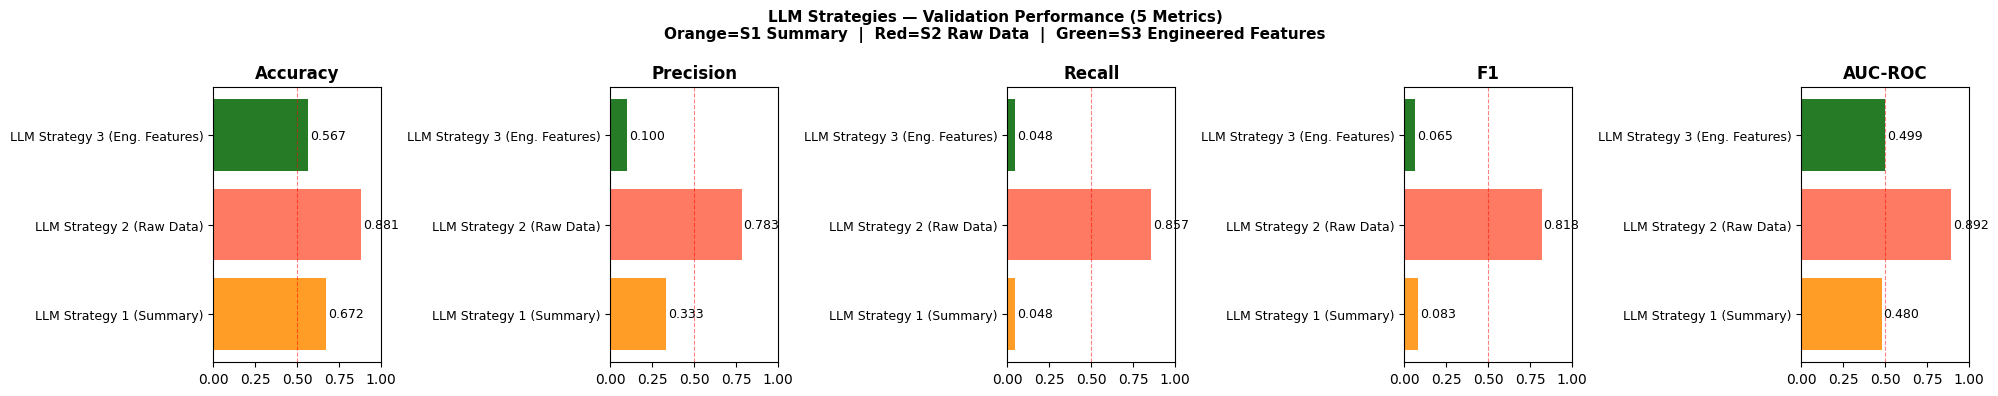

In [34]:
# ─── Visualization: LLM Strategy Comparison ───────────────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
colors   = ['darkorange', 'tomato', 'darkgreen']
strategies = all_metrics['Strategy']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.barh(strategies, all_metrics[metric], color=colors, alpha=0.85)
    ax.set_xlim(0, 1)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.axvline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, val in zip(bars, all_metrics[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)

fig.suptitle(
    'LLM Strategies — Validation Performance (5 Metrics)\n'
    'Orange=S1 Summary  |  Red=S2 Raw Data  |  Green=S3 Engineered Features',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

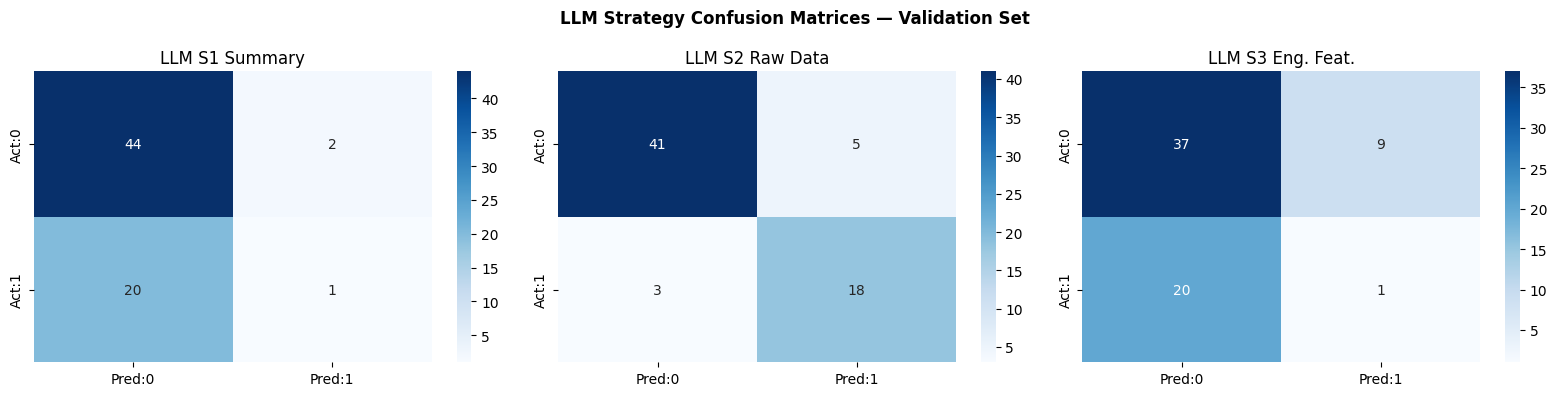

=== Spearman Rank Correlation Between LLM Strategies ===
  S1 vs S2: r=0.170, p=0.1698
  S1 vs S3: r=-0.047, p=0.7082
  S2 vs S3: r=0.293, p=0.0161


In [35]:
# ─── Confusion matrices for all 3 LLM strategies ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (label, df_s) in zip(axes, [
    ('LLM S1 Summary',    df_strat1),
    ('LLM S2 Raw Data',   df_strat2),
    ('LLM S3 Eng. Feat.', df_strat3),
]):
    cm = confusion_matrix(y_true, df_s['predicted_ordered'].values)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred:0','Pred:1'],
                yticklabels=['Act:0','Act:1'])
    ax.set_title(label)
plt.suptitle('LLM Strategy Confusion Matrices — Validation Set', fontweight='bold')
plt.tight_layout()
plt.savefig('llm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Spearman rank correlation between LLM strategies ─────────────────────────
print("=== Spearman Rank Correlation Between LLM Strategies ===")
pairs = [
    ('S1', 'S2', df_strat1, df_strat2),
    ('S1', 'S3', df_strat1, df_strat3),
    ('S2', 'S3', df_strat2, df_strat3),
]
for a_label, b_label, df_a, df_b in pairs:
    corr, p = spearmanr(
        df_a['purchase_probability'].values,
        df_b['purchase_probability'].values
    )
    print(f"  {a_label} vs {b_label}: r={corr:.3f}, p={p:.4f}")

---
## E. Consolidated CSV Output

In [36]:
# ─── Build full validation results CSV (LLM strategies only) ──────────────────
df_output = df_val[['title','image','price','ordered','image_path']].copy().reset_index(drop=True)

eng_cols_to_add = [c for c in ENG_FEATURE_COLS if c != 'ordered' and c in df_val.columns]
df_output = pd.concat([df_output, df_val[eng_cols_to_add].reset_index(drop=True)], axis=1)

for df_s, prefix in [
    (df_strat1, 'llm_s1'),
    (df_strat2, 'llm_s2'),
    (df_strat3, 'llm_s3'),
]:
    df_output[f'{prefix}_prob']      = df_s['purchase_probability'].values
    df_output[f'{prefix}_pred']      = df_s['predicted_ordered'].values
    df_output[f'{prefix}_score']     = df_s['purchase_score'].values
    df_output[f'{prefix}_rec']       = df_s['recommendation'].values
    df_output[f'{prefix}_rationale'] = df_s['rationale'].values

df_output.to_csv('validation_results_full.csv', index=False)
print(f"✅ Saved validation_results_full.csv  |  Shape: {df_output.shape}")
print(df_output.head(3))

✅ Saved validation_results_full.csv  |  Shape: (67, 30)
                                               title  \
0  Men's Cotton Linen Casual Long Sleeve Shirt Li...   
1  Men's Summer Solid Color Comfortable V-neck Sh...   
2   Men's Cotton Knit Striped Polo Shirt Khaki / 4XL   

                                               image  price  ordered  \
0  http://t3.gstatic.com/shopping?q=tbn:ANd9GcSwp...  35.44        1   
1  http://t3.gstatic.com/shopping?q=tbn:ANd9GcQ1q...  18.86        0   
2  http://t0.gstatic.com/shopping?q=tbn:ANd9GcTWc...  36.06        1   

  image_path  price gender material product_type sleeve_or_neck  ...  \
0    image_0  35.44    Men   Cotton        Shirt    Long Sleeve  ...   
1  image_219  18.86    Men  unknown      T-Shirt         V-Neck  ...   
2  image_217  36.06    Men   Cotton         Polo        unknown  ...   

  llm_s2_prob llm_s2_pred llm_s2_score llm_s2_rec  \
0        0.72           1          7.0     SELECT   
1        0.25           0          

---
## F. Final Product Selection — Apply to dataset_new.csv

In [38]:
# ── No ML predictions — LLM-only comparison ───────────────────────────────────
# df_new_s1, df_new_s2, df_new_s3 are already loaded from cache above

df_compare = pd.DataFrame({
    'Title':   df_new['title'].str[:45].values,
    'Price':   df_new['price'].values,
    'S1_prob': df_new_s1['purchase_probability'].values,
    'S1_rec':  df_new_s1['recommendation'].values,
    'S2_prob': df_new_s2['purchase_probability'].values,
    'S2_rec':  df_new_s2['recommendation'].values,
    'S3_prob': df_new_s3['purchase_probability'].values,
    'S3_rec':  df_new_s3['recommendation'].values,
})

rec_cols = ['S1_rec','S2_rec','S3_rec']
df_compare['Votes_SELECT'] = df_compare[rec_cols].apply(
    lambda row: (row == 'SELECT').sum(), axis=1
)
df_compare['Consensus'] = df_compare['Votes_SELECT'].apply(
    lambda v: 'STRONG SELECT' if v == 3
         else ('LEAN SELECT'  if v == 2
         else ('LEAN SKIP'    if v == 1 else 'STRONG SKIP'))
)

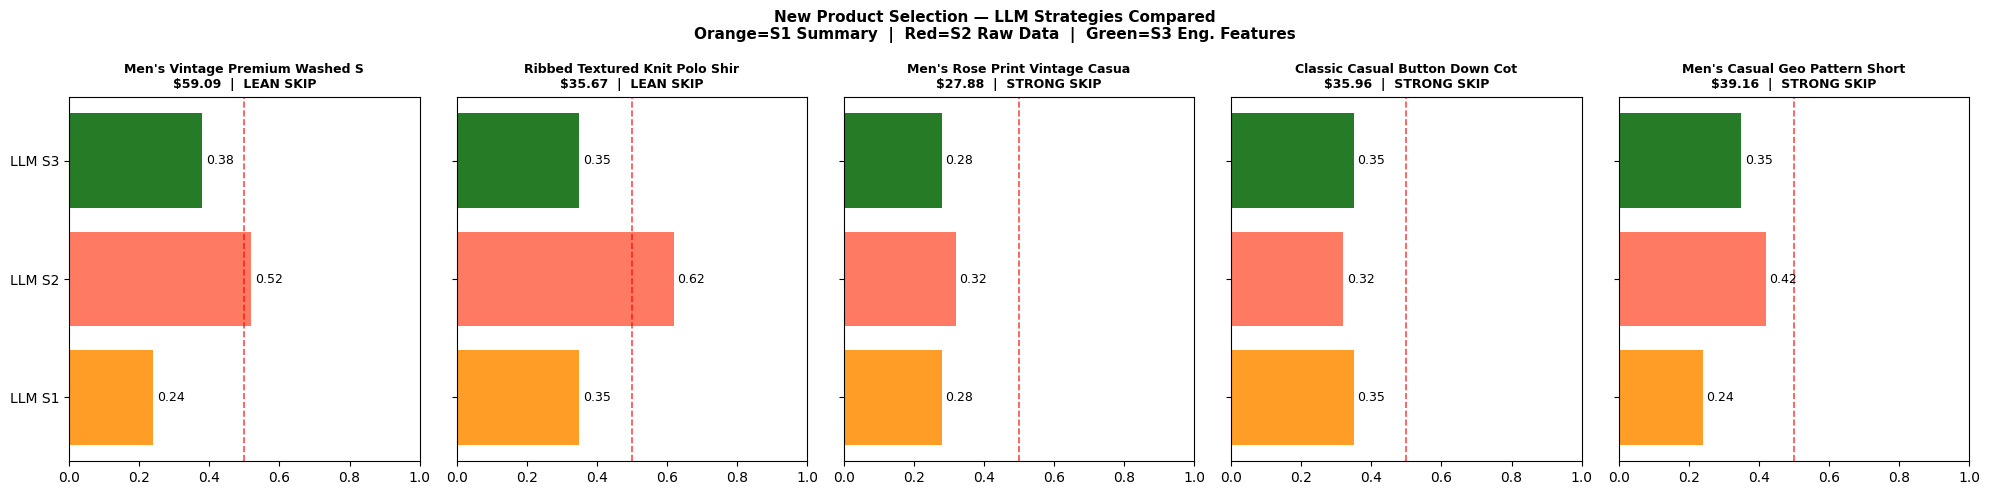

In [39]:
# ── Visualization (LLM strategies only) ───────────────────────────────────────
model_cols   = ['S1_prob','S2_prob','S3_prob']
model_labels = ['LLM S1','LLM S2','LLM S3']
bar_colors   = ['darkorange','tomato','darkgreen']

n_products = len(df_compare)
fig, axes  = plt.subplots(1, n_products, figsize=(4 * n_products, 5), sharey=True)
if n_products == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, df_compare.iterrows()):
    probs = [row[c] for c in model_cols]
    bars  = ax.barh(model_labels, probs, color=bar_colors, alpha=0.85)
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_xlim(0, 1)
    ax.set_title(
        f"{row['Title'][:30]}\n${row['Price']}  |  {row['Consensus']}",
        fontsize=9, fontweight='bold'
    )
    for bar, val in zip(bars, probs):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=9)

fig.suptitle(
    'New Product Selection — LLM Strategies Compared\n'
    'Orange=S1 Summary  |  Red=S2 Raw Data  |  Green=S3 Eng. Features',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('new_product_selection.png', dpi=150, bbox_inches='tight')
plt.show()